# EDA hệ SINACON PV (APS/APU) — có đối chiếu tài liệu kỹ thuật hãng

Notebook này đọc dữ liệu **đã gộp** từ `aps_apu_cleaner.py` (thư mục
`cleaned_data/`) và khám phá dữ liệu **có đối chiếu với tài liệu kỹ thuật
chính hãng** — *SINACON PV Photovoltaic Central Inverter, Operating
Instructions 01/2020* (file PDF bạn cung cấp).

**Xác nhận quan trọng:** định dạng file log và tên/ý nghĩa từng cột trong
`cleaned_data/` khớp **chính xác 100%** với mục *"10.5 Log files"* của tài
liệu — nghĩa là bước làm sạch dữ liệu trước đó là đúng.

Notebook dùng thêm 2 nguồn tra cứu lấy từ tài liệu để dữ liệu "có ý nghĩa"
hơn chỉ là con số:

- **Mục 10.1/10.3** — bảng mã lỗi (Error) và cảnh báo (Warning) → dùng để
  **giải mã** các cột `Error1..8` / `Err1..8` / `Warning1..8` thành mô tả
  thay vì mã số vô nghĩa.
- **Mục 12.3** — thông số điện định mức (công suất, điện áp, dòng điện) theo
  từng lớp điện áp lưới (550/575/600/630/660/690 V) → dùng để so sánh dữ liệu
  đo được với định mức thiết bị (thiết bị đang chạy bao nhiêu % công suất?).

> ⚠️ Thiết bị của bạn có 4 APU. Notebook mặc định dùng bảng định mức lớp
> **550 V** — đây là giá trị phổ biến nhất trong tài liệu, nhưng bạn nên
> **đối chiếu lại với nhãn máy thực tế** (mục `RATED_SPECS`, đổi
> `AC_VOLTAGE_CLASS` nếu khác) để số % tải chính xác.

> **Trước khi chạy:** đặt notebook này cùng cấp với thư mục `cleaned_data/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CLEANED_DIR = Path("cleaned_data")   # doi lai neu ban de o cho khac

def load_table(log_type_slug: str) -> pd.DataFrame:
    path = CLEANED_DIR / f"{log_type_slug}.csv"
    return pd.read_csv(path, parse_dates=["TimeStamp"])

## 1. Bảng tra cứu lấy từ tài liệu kỹ thuật

### 1.1 Mã lỗi / cảnh báo (mục 10.1, 10.3)

Có **2 bảng lỗi khác nhau** theo tài liệu:
- `Error1..8` (trong `APS Stat Trig`) → lỗi cấp **toàn hệ thống**, tra theo
  bảng *"Error messages for the complete inverter unit"*
- `Err1..8` (trong `APU Stat Trig`) → lỗi cấp **từng APU**, tra theo bảng
  *"Error messages for the inverter subunit"*
- `Warning1..8` chỉ xuất hiện ở `APS Stat Trig`, tra theo bảng *"Warning
  messages"*

In [2]:
ERROR_CODES_APS = {
    1: "Modbus TCP value out of range", 2: "Configuration corrupt",
    3: "APU 1/2 cooling fluid low", 4: "APU 3/4 cooling fluid low",
    5: "No enable signal", 6: "No supply voltage",
    7: "Medium voltage switch gear off", 8: "DI Temperature not OK",
    9: "DI medium voltage transformer error",
    10: "APU 1/2 water pump switching cycles", 11: "APU 3/4 water pump switching cycles",
    12: "APU 5/6 water pump switching cycles",
    13: "APU 1/2 air-to-air cooler switching cycles", 14: "APU 3/4 air-to-air cooler switching cycles",
    15: "APU 5/6 air-to-air cooler switching cycles",
    16: "APU 1/2 water air cooler switching cycles", 17: "APU 3/4 water air cooler switching cycles",
    18: "APU 5/6 water air cooler switching cycles",
    19: "Supply voltage low", 20: "Modbus TCP timeout",
    21: "APU 1/2 insulation", 22: "APU 3/4 insulation", 23: "APU 5/6 insulation",
    24: "Medium voltage transformer temperature high", 25: "APU 5/6 cooling fluid low",
    26: "Error count overrun",
    27: "APU 1/2 insulation monitor failed", 28: "APU 3/4 insulation monitor failed",
    29: "APU 5/6 insulation monitor failed",
    30: "APU 1 Powerlink", 31: "APU 2 Powerlink", 32: "APU 3 Powerlink",
    33: "APU 4 Powerlink", 34: "APU 5 Powerlink", 35: "APU 6 Powerlink",
    36: "APU 1 type mismatch", 37: "APU 2 type mismatch", 38: "APU 3 type mismatch",
    39: "APU 4 type mismatch", 40: "APU 5 type mismatch", 41: "APU 6 type mismatch",
    42: "APS unlicensed", 43: "Internal configuration not valid", 44: "APU Update",
    45: "APMC - Battery missing/empty",
    46: "APU1/2 Insulation Monitoring (pos. ground)", 47: "APU3/4 Insulation Monitoring (pos. ground)",
    48: "APU1/2 Insulation Monitoring (neg. ground)", 49: "APU3/4 Insulation Monitoring (neg. ground)",
    50: "APU1/2 extern Insulation Monitoring", 51: "APU3/4 extern Insulation Monitoring",
    53: "APU1/2 high Temperature", 54: "APU3/4 high Temperature",
    55: "APU1/2 Island Fuses", 56: "APU3/4 Island Fuses", 57: "Humidity too high",
}

ERROR_CODES_APU = {
    1: "Overtemperature IGBT L1", 2: "Overtemperature IGBT L2", 3: "Overtemperature IGBT L3",
    4: "Overtemperature inductance",
    5: "Overvoltage Vdc pos. SW", 6: "Overvoltage Vdc neg. SW", 7: "Overvoltage Vdc total SW",
    8: "Undervoltage Vdc pos. SW", 9: "Undervoltage Vdc neg. SW", 10: "Undervoltage Vdc total SW",
    11: "Overcurrent Idc SW", 12: "Overcurrent Iac L1 SW", 13: "Overcurrent Iac L2 SW",
    14: "Overcurrent Iac L3 SW", 16: "Grid rotation Error",
    17: "Overfrequency level 1", 18: "Overfrequency level 2", 19: "Overfrequency level 3",
    20: "Underfrequency level 1", 21: "Underfrequency level 2",
    22: "Overvoltage VL1 level 1", 23: "Overvoltage VL1 level 2", 24: "Overvoltage VL1 level 3",
    25: "Overvoltage VL2 level 1", 26: "Overvoltage VL2 level 2", 27: "Overvoltage VL2 level 3",
    28: "Overvoltage VL3 level 1", 29: "Overvoltage VL3 level 2", 30: "Overvoltage VL3 level 3",
    31: "Undervoltage VL1 level 1", 32: "Undervoltage VL1 level 2",
    33: "Undervoltage VL2 level 1", 34: "Undervoltage VL2 level 2",
    35: "Undervoltage VL3 level 1", 36: "Undervoltage VL3 level 2",
    37: "Driver L1", 38: "Driver L2", 39: "Driver L3",
    40: "Overcurrent Idc HW", 41: "Overcurrent Iac L1 HW", 42: "Overcurrent Iac L2 HW",
    43: "Overcurrent Iac L3 HW", 44: "Overtemperature IGBT HW",
    46: "Supply error", 47: "Supply error delayed",
    48: "Overvoltage Vdc neg. HW", 49: "Undervoltage Vdc neg. HW",
    50: "Overvoltage Vdc pos. HW", 51: "Undervoltage Vdc pos. HW", 52: "Overvoltage Vdc total HW",
    53: "Supply error 15V neg. SW", 54: "Supply error 15V pos. sum. SW",
    56: "Supply error 24V driver pos. SW", 57: "Supply error 24V neg. SW",
    58: "Supply error 24V pos. SW", 59: "Supply error 5V pos. SW",
    60: "AC switch", 61: "DC switch", 62: "Enable 24V",
    63: "Driver version L1", 64: "Driver version L2", 65: "Driver version L3",
    66: "CPLD version", 67: "HW control card", 68: "Model control card",
    69: "AC pre-charge", 70: "DC pre-charge", 71: "Sector synchronisation",
    72: "No sync. signal", 73: "Wrong firmware version", 74: "Wrong control mode",
    75: "Current sum error", 76: "Driver L1 (booster)", 77: "Driver L2 (booster)",
    78: "Driver L3 (booster)", 79: "Overcurrent Idc HW", 80: "Overcurrent Iac L1 HW",
    81: "Overcurrent Iac L2 HW", 82: "Overcurrent Iac L3 HW", 83: "PWM error",
    84: "Overvoltage Vdc neg. HW", 85: "Undervoltage Vdc neg. HW",
    86: "Overvoltage Vdc pos. HW", 87: "Undervoltage Vdc pos. HW", 88: "Overvoltage Vdc total HW",
    89: "Overtemperature IGBT HW", 90: "Overcurrent Booster HW", 91: "Driver Chopper",
    92: "Supply error", 93: "Supply error delayed", 94: "Driver Booster", 95: "No driver detected",
    96: "Overvoltage VL1 level 4", 97: "Overvoltage VL2 level 4", 98: "Overvoltage VL3 level 4",
    99: "Overvoltage mean level 1",
    100: "Overtemperature Control Card SW", 101: "Wrong version control card",
    102: "Voltage measurement Island grid", 103: "Unbalanced grid voltage",
    104: "Unbalanced phase angle", 105: "Unbalanced grid current",
    106: "Overcurrent Idc SW pos", 107: "Overcurrent Idc SW neg",
    108: "Undervoltage VL1 level 3", 109: "Undervoltage VL2 level 3", 110: "Undervoltage VL3 level 3",
    111: "Discharge Udc pos", 112: "Discharge Udc neg",
    113: "Wrong Op mode for overcurrent test", 114: "Wrong variant to Uac nom",
}

WARNING_CODES = {
    1: "APU 1/2 cooling fluid low", 2: "APU 3/4 cooling fluid low",
    3: "Time synchronisation failed", 4: "Modbus RTU (Display)",
    5: "AC surge arrester tripped", 6: "DC surge arrester tripped",
    7: "APU 1/2 insulation monitor failed", 8: "APU 3/4 insulation monitor failed",
    9: "APU 5/6 insulation monitor failed",
    10: "APU 1/2 insulation level 2", 11: "APU 3/4 insulation level 2", 12: "APU 5/6 insulation level 2",
    13: "APU 1/2 insulation level 1", 14: "APU 3/4 insulation level 1", 15: "APU 5/6 insulation level 1",
    22: "APU 1 error", 23: "APU 2 error", 24: "APU 3 error", 25: "APU 4 error",
    29: "APU 1 Powerlink", 30: "APU 2 Powerlink", 31: "APU 3 Powerlink", 32: "APU 4 Powerlink",
    35: "Power limit transformer", 36: "Power limit ambient",
    37: "APU 1 error counter overrun", 38: "APU 2 error counter overrun",
    39: "APU 3 error counter overrun", 40: "APU 4 error counter overrun",
    43: "APU in manual mode", 44: "Cooling in manual mode", 45: "Heating in manual mode",
    46: "APU in service mode", 47: "Log samples lost",
    48: "APU 1/2 current measurement", 49: "APU 3/4 current measurement",
    51: "APU 1/2 Powerlink flicker", 52: "APU 3/4 Powerlink flicker",
    54: "APU1/2 insulation monitoring (pos. ground)", 55: "APU3/4 insulation monitoring (pos. ground)",
    56: "APU1/2 insulation monitoring (neg. ground)", 57: "APU3/4 insulation monitoring (neg. ground)",
    58: "APU1/2 extern insulation monitoring", 59: "APU3/4 extern insulation monitoring",
    60: "USB-device almost full", 61: "USB-device full", 62: "CMB update", 63: "IMD update",
    64: "Max ModbusTCP master exceeded",
    65: "APU 1 disable", 66: "APU 2 disable", 67: "APU 3 disable", 68: "APU 4 disable",
    69: "USB-Device failed",
}

print(f"Da nap {len(ERROR_CODES_APS)} ma loi APS, {len(ERROR_CODES_APU)} ma loi APU, "
      f"{len(WARNING_CODES)} ma canh bao — tu tai lieu ky thuat (muc 10.1 / 10.3).")

Da nap 56 ma loi APS, 111 ma loi APU, 54 ma canh bao — tu tai lieu ky thuat (muc 10.1 / 10.3).


### 1.2 Thông số định mức (mục 12.3 — Electrical data)

Bảng cho cấu hình **4 APU** (đúng bằng số APU trong dữ liệu bạn có), theo
từng lớp điện áp lưới AC.

In [3]:
# Cong suat/dong dien la TONG CA TRAM (4 APU cong lai), khong phai tung APU rieng.
RATED_SPECS = {
    550: {"Vac_nom_V": 550, "Pdc_nom_kW": 4064, "Pac_nom_kW": 4000, "Vdc_max_V": 1500, "Vdc_nom_V": 1000, "Idc_max_A": 4800},
    575: {"Vac_nom_V": 575, "Pdc_nom_kW": 4248, "Pac_nom_kW": 4180, "Vdc_max_V": 1500, "Vdc_nom_V": 1000, "Idc_max_A": 4800},
    600: {"Vac_nom_V": 600, "Pdc_nom_kW": 4432, "Pac_nom_kW": 4360, "Vdc_max_V": 1500, "Vdc_nom_V": 1000, "Idc_max_A": 4800},
    630: {"Vac_nom_V": 630, "Pdc_nom_kW": 4636, "Pac_nom_kW": 4560, "Vdc_max_V": 1500, "Vdc_nom_V": 1000, "Idc_max_A": 4800},
    660: {"Vac_nom_V": 660, "Pdc_nom_kW": 4880, "Pac_nom_kW": 4800, "Vdc_max_V": 1500, "Vdc_nom_V": 1100, "Idc_max_A": 4800},
    690: {"Vac_nom_V": 690, "Pdc_nom_kW": 5081, "Pac_nom_kW": 4560, "Vdc_max_V": 1500, "Vdc_nom_V": 1100, "Idc_max_A": 4800},
}

AC_VOLTAGE_CLASS = 550   # DOI LAI o day neu nhan may cua ban ghi lop dien ap khac
specs = RATED_SPECS[AC_VOLTAGE_CLASS]
print("Dinh muc dang dung (toan tram, 4 APU):", specs)

Dinh muc dang dung (toan tram, 4 APU): {'Vac_nom_V': 550, 'Pdc_nom_kW': 4064, 'Pac_nom_kW': 4000, 'Vdc_max_V': 1500, 'Vdc_nom_V': 1000, 'Idc_max_A': 4800}


## 2. Đọc dữ liệu

In [4]:
stat10s = load_table("apu_stat_10s")
stat10s["Date"] = stat10s["TimeStamp"].dt.date
stat10s["Hour"] = stat10s["TimeStamp"].dt.hour
systems = sorted(stat10s["System"].unique())

print("Cac System trong du lieu:", systems)
print("Khoang thoi gian:", stat10s["TimeStamp"].min(), "->", stat10s["TimeStamp"].max())

Cac System trong du lieu: ['APU 1', 'APU 2', 'APU 3', 'APU 4']
Khoang thoi gian: 2025-10-01 00:00:00 -> 2025-10-27 09:09:00


## 8. Giải mã sự kiện lỗi/cảnh báo bằng tài liệu kỹ thuật

Khác với trước (chỉ đếm theo mã số), giờ mỗi mã được **dịch sang mô tả thật**
lấy từ mục 10.1/10.3 của tài liệu — dễ đọc và có thể tra nguyên nhân/khắc phục
trực tiếp trong tài liệu gốc theo đúng tên lỗi.

In [10]:
def extract_events(df: pd.DataFrame, code_cols_prefix: str, code_map: dict) -> pd.DataFrame:
    event_cols = [c for c in df.columns if re.match(rf"^{code_cols_prefix}\d+$", c)]
    if not event_cols:
        return pd.DataFrame()
    long = df.melt(id_vars=["System", "TimeStamp"], value_vars=event_cols,
                    var_name="Cot", value_name="Ma")
    long = long[long["Ma"] != 0].copy()
    long["Ma"] = long["Ma"].astype("Int64")
    long["Mo ta"] = long["Ma"].map(code_map).fillna("Mã không xác định: " + long["Ma"].astype(str))
    return long

events_parts = []

aps_trig_path = CLEANED_DIR / "aps_stat_trig.csv"
if aps_trig_path.exists():
    df = load_table("aps_stat_trig")
    ev = extract_events(df, "Error", ERROR_CODES_APS)
    if len(ev):
        ev["Nhom"] = "APS - Error"
        events_parts.append(ev)
    ev = extract_events(df, "Warning", WARNING_CODES)
    if len(ev):
        ev["Nhom"] = "APS - Warning"
        events_parts.append(ev)

apu_trig_path = CLEANED_DIR / "apu_stat_trig.csv"
if apu_trig_path.exists():
    df = load_table("apu_stat_trig")
    ev = extract_events(df, "Error", ERROR_CODES_APU)  # FIX: du lieu that dung "Error1..8", khong phai "Err1..8" nhu trong tai lieu in
    if len(ev):
        ev["Nhom"] = "APU - Error"
        events_parts.append(ev)

if events_parts:
    events = pd.concat(events_parts, ignore_index=True)
    print(f"Tong so lan kich hoat: {len(events)}")
else:
    events = pd.DataFrame()
    print("Không có sự kiện Error/Warning nào trong dữ liệu này.")

Tong so lan kich hoat: 6574


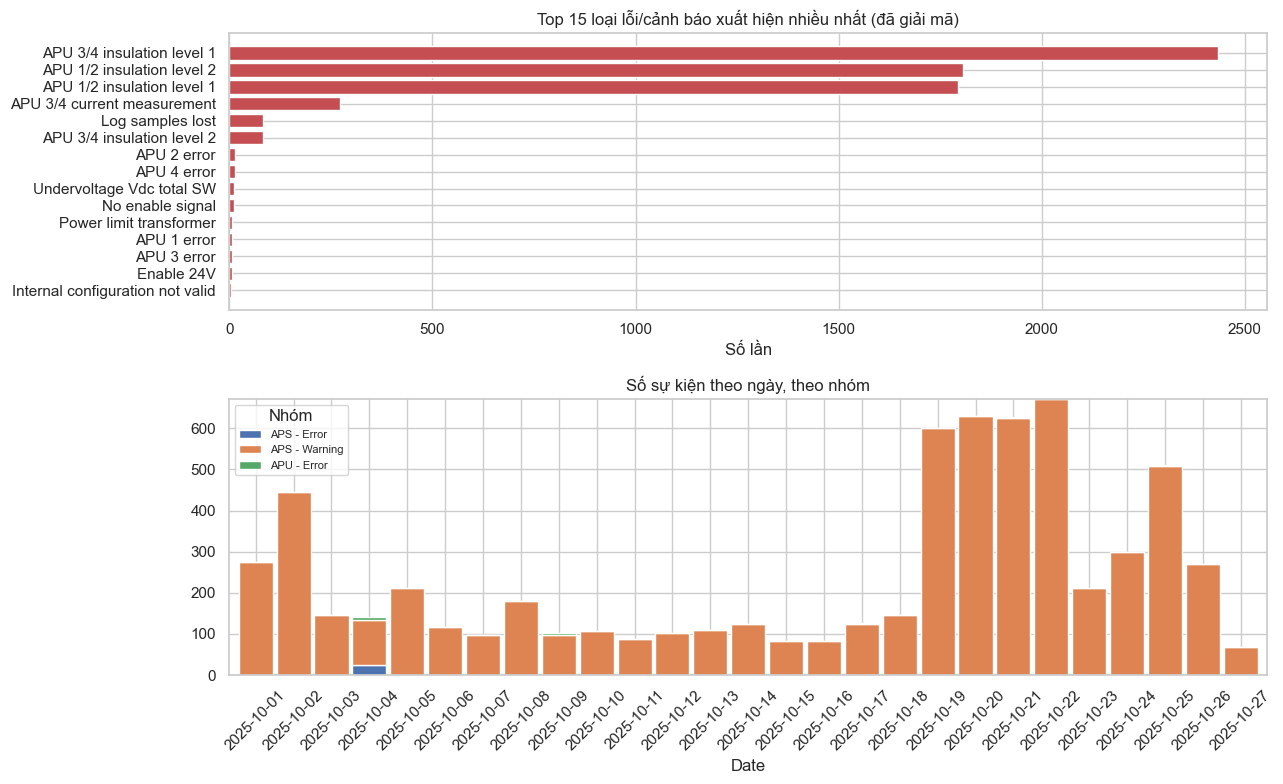

In [31]:
if len(events):
    fig, axes = plt.subplots(2, 1, figsize=(13, 8))

    top_events = events["Mo ta"].value_counts().head(15)
    axes[0].barh(top_events.index[::-1], top_events.values[::-1], color="#C44E52")
    axes[0].set_title("Top 15 loại lỗi/cảnh báo xuất hiện nhiều nhất (đã giải mã)")
    axes[0].set_xlabel("Số lần")

    events["Date"] = events["TimeStamp"].dt.date
    daily_counts = events.groupby(["Date", "Nhom"]).size().unstack(fill_value=0)
    daily_counts.plot(kind="bar", stacked=True, ax=axes[1], width=0.9)
    axes[1].set_title("Số sự kiện theo ngày, theo nhóm")
    axes[1].legend(title="Nhóm", fontsize=8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 14. Bảng điều khiển theo 1 ngày cụ thể (dùng cho trình bày)

Mục này gộp **cả 6 loại log cấp APS** (`APS Ctrl Trig`, `APS Energy`,
`APS Stat 10s`, `APS Stat 60s`, `APS Stat Trig`, `APS Switching Cycles`) vào
**1 hình duy nhất cho 1 ngày bạn chọn** — đúng phong cách trình bày: chọn ngày,
chạy, ra hình ngay.

**Mục tiêu:** khớp thời gian giữa các log để thấy quan hệ **mắt thường không
thấy được** nếu chỉ nhìn số — ví dụ: warning nhiệt độ xảy ra đúng lúc hệ làm mát
chưa kịp bật, hay lỗi xảy ra đúng lúc sản lượng đang lên đỉnh.

Đổi `SELECTED_DATE` ở cell cuối cùng rồi chạy lại — không cần chạy lại từ đầu.

In [32]:
OPSTATE_MAP = {
    0: "Save energy", 30: "Booting", 50: "Off",
    100: "Initializing DC", 130: "Waiting (DC)", 160: "Precharging DC",
    200: "DC connection", 300: "AC connection status", 330: "Initializing AC",
    360: "Waiting (AC)", 400: "Precharging AC", 500: "AC connection",
    3000: "MPPT mode active", 10000: "Test bench mode",
}

def _state_at_day_start(df, day, value_cols):
    """Lay dong gan nhat TRUOC 00:00 ngay `day`, dung lam gia tri khoi dau
    cho cac bang trigger (chi ghi khi thay doi) de duong ve khong bi 'trong'
    tu dau ngay cho toi lan thay doi dau tien."""
    day_start = pd.Timestamp(day)
    before = df[df["TimeStamp"] < day_start]
    if before.empty:
        return None
    last_row = before.sort_values("TimeStamp").iloc[[-1]].copy()
    last_row["TimeStamp"] = day_start
    return last_row[["TimeStamp"] + value_cols]

def _day_slice(df, day):
    day_start = pd.Timestamp(day)
    day_end = day_start + pd.Timedelta(days=1)
    return df[(df["TimeStamp"] >= day_start) & (df["TimeStamp"] < day_end)].sort_values("TimeStamp")

print("Da dinh nghia ham dung chung cho dashboard theo ngay.")

Da dinh nghia ham dung chung cho dashboard theo ngay.


In [ ]:
def plot_day_dashboard(date_str: str):
    day = pd.Timestamp(date_str).normalize()
    day_start, day_end = day, day + pd.Timedelta(days=1)

    aps_trig = load_table("aps_stat_trig")
    aps_ctrl = load_table("aps_ctrl_trig")
    aps60s = load_table("aps_stat_60s")
    aps_sw = load_table("aps_switching_cycles")
    aps_en = load_table("aps_energy")
    aps10s_path = CLEANED_DIR / "aps_stat_10s.csv"
    aps10s = load_table("aps_stat_10s") if aps10s_path.exists() else pd.DataFrame()

    fig, axes = plt.subplots(
        6, 1, figsize=(14, 16), sharex=True,
        gridspec_kw={"height_ratios": [1.3, 0.9, 1.3, 1.3, 1.6, 1.1]}
    )
    ax_events, ax_state, ax_temp, ax_riso, ax_ctrl, ax_energy = axes

    # ---- Row 1: Error / Warning timeline (do = Error, xanh = Warning) ----
    trig_day = _day_slice(aps_trig, day)
    err_cols = [c for c in trig_day.columns if re.match(r"^Error\d+$", c)]
    warn_cols = [c for c in trig_day.columns if re.match(r"^Warning\d+$", c)]

    def melt_events(df, cols, code_map):
        if not cols or df.empty:
            return pd.DataFrame(columns=["TimeStamp", "Ma", "Mo ta"])
        long = df.melt(id_vars=["TimeStamp"], value_vars=cols, value_name="Ma")
        long = long[long["Ma"] != 0].copy()
        long["Ma"] = long["Ma"].astype(int)
        long["Mo ta"] = long["Ma"].map(code_map).fillna("Mã " + long["Ma"].astype(str))
        return long

    errs = melt_events(trig_day, err_cols, ERROR_CODES_APS)
    warns = melt_events(trig_day, warn_cols, WARNING_CODES)

    if len(errs):
        ax_events.scatter(errs["TimeStamp"], [1] * len(errs), color="red", s=70,
                           marker="o", label=f"Error ({len(errs)})", zorder=3)
        for _, r in errs.iterrows():
            ax_events.annotate(r["Mo ta"], (r["TimeStamp"], 1), xytext=(0, 8),
                                textcoords="offset points", fontsize=7, color="red",
                                rotation=25, ha="left")
    if len(warns):
        ax_events.scatter(warns["TimeStamp"], [0] * len(warns), color="#3778BF", s=50,
                           marker="o", label=f"Warning ({len(warns)})", zorder=3)
        for _, r in warns.iterrows():
            ax_events.annotate(r["Mo ta"], (r["TimeStamp"], 0), xytext=(0, -14),
                                textcoords="offset points", fontsize=7, color="#3778BF",
                                rotation=-25, ha="left")

    ax_events.set_yticks([0, 1])
    ax_events.set_yticklabels(["Warning", "Error"])
    ax_events.set_ylim(-0.6, 1.6)
    ax_events.set_title(f"Sự kiện Error/Warning cấp APS — {day.date()}", fontsize=11, loc="left")
    if len(errs) or len(warns):
        ax_events.legend(loc="upper right", fontsize=8)
    else:
        ax_events.text(0.5, 0.5, "Không có Error/Warning nào trong ngày này",
                        transform=ax_events.transAxes, ha="center", color="gray")

    # ---- Row 2: OpState ----
    state_start = _state_at_day_start(aps_trig, day, ["OpState"])
    state_day = trig_day[["TimeStamp", "OpState"]] if "OpState" in trig_day.columns else pd.DataFrame()
    state_all = pd.concat([state_start, state_day], ignore_index=True) if state_start is not None else state_day
    if len(state_all):
        state_all = state_all.sort_values("TimeStamp")
        ax_state.step(state_all["TimeStamp"], state_all["OpState"], where="post", color="#55A868")
        present_codes = sorted(state_all["OpState"].dropna().unique())
        ax_state.set_yticks(present_codes)
        ax_state.set_yticklabels([OPSTATE_MAP.get(int(c), str(c)) for c in present_codes], fontsize=8)
    ax_state.set_title("Trạng thái vận hành (OpState)", fontsize=11, loc="left")

    # ---- Row 3: Nhiet do ----
    temp_day = _day_slice(aps60s, day)
    for c, color in zip(["Tamb/°C", "Tpan/°C", "Ttrans/°C"], ["#4C72B0", "#DD8452", "#C44E52"]):
        if c in temp_day.columns:
            ax_temp.plot(temp_day["TimeStamp"], temp_day[c], label=c, color=color, linewidth=1)
    ax_temp.set_ylabel("°C")
    ax_temp.legend(fontsize=8, loc="upper right")
    ax_temp.set_title("Nhiệt độ môi trường / tấm pin / biến áp", fontsize=11, loc="left")

    # ---- Row 4: Cach dien (Riso) + ro ri (Cleak) ----
    riso_cols = [c for c in ["Riso12/k", "Riso34/kO", "Riso56/kO"] if c in temp_day.columns]
    cleak_cols = [c for c in ["Cleak12/µF", "Cleak34/µF", "Cleak56/µF"] if c in temp_day.columns]
    for c in riso_cols:
        ax_riso.plot(temp_day["TimeStamp"], temp_day[c], label=c, linewidth=1)
    ax_riso.set_ylabel("Riso (kΩ)")
    ax_riso.legend(fontsize=7, loc="upper left")
    if cleak_cols:
        ax_riso2 = ax_riso.twinx()
        for c in cleak_cols:
            ax_riso2.plot(temp_day["TimeStamp"], temp_day[c], label=c, linestyle="--", linewidth=1, alpha=0.6)
        ax_riso2.set_ylabel("Cleak (µF)")
        ax_riso2.legend(fontsize=7, loc="upper right")
    ax_riso.set_title("Điện trở cách điện & điện dung rò rỉ", fontsize=11, loc="left")

    # ---- Row 5: Trang thai dieu khien (Ctrl Trig) dang Gantt ----
    ctrl_state_cols = ["WaterAir1State", "WaterAir2State", "WaterPump1", "WaterPump2",
                        "DehumidifierOn", "HeatingOn", "EnableOn"]
    ctrl_state_cols = [c for c in ctrl_state_cols if c in aps_ctrl.columns]
    start_row = _state_at_day_start(aps_ctrl, day, ctrl_state_cols)
    ctrl_day = _day_slice(aps_ctrl, day)[["TimeStamp"] + ctrl_state_cols] if len(ctrl_state_cols) else pd.DataFrame()
    ctrl_all = pd.concat([start_row, ctrl_day], ignore_index=True) if start_row is not None else ctrl_day
    ctrl_all = pd.concat([ctrl_all, pd.DataFrame({"TimeStamp": [day_end]})], ignore_index=True) if len(ctrl_all) else ctrl_all

    if len(ctrl_all):
        ctrl_all = ctrl_all.sort_values("TimeStamp").ffill()
        for i, col in enumerate(ctrl_state_cols):
            on_mask = ctrl_all[col] > 0
            t = ctrl_all["TimeStamp"].values
            segs = []
            seg_start = None
            for j in range(len(ctrl_all)):
                if on_mask.iloc[j] and seg_start is None:
                    seg_start = t[j]
                elif not on_mask.iloc[j] and seg_start is not None:
                    segs.append((seg_start, t[j]))
                    seg_start = None
            if seg_start is not None:
                segs.append((seg_start, day_end))
            for s, e in segs:
                ax_ctrl.barh(i, (pd.Timestamp(e) - pd.Timestamp(s)), left=pd.Timestamp(s),
                              height=0.6, color="#55A868")
        ax_ctrl.set_yticks(range(len(ctrl_state_cols)))
        ax_ctrl.set_yticklabels(ctrl_state_cols, fontsize=8)
        ax_ctrl.set_ylim(-0.6, len(ctrl_state_cols) - 0.4)
    ax_ctrl.set_title("Trạng thái điều khiển (xanh = đang BẬT)", fontsize=11, loc="left")

    # ---- Row 6: San luong trong ngay (delta) + Irr neu co ----
    en_day = _day_slice(aps_en, day)
    if len(en_day) and "W_out_APS/kWh" in en_day.columns:
        base = en_day["W_out_APS/kWh"].iloc[0]
        ax_energy.plot(en_day["TimeStamp"], en_day["W_out_APS/kWh"] - base,
                        color="#4C72B0", label="Sản lượng cộng dồn trong ngày (kWh)")
        ax_energy.set_ylabel("kWh (từ đầu ngày)")
        ax_energy.legend(loc="upper left", fontsize=8)
    if len(aps10s):
        irr_day = _day_slice(aps10s, day)
        if len(irr_day) and "Irr/(W/m²)" in irr_day.columns and irr_day["Irr/(W/m²)"].notna().any():
            ax_irr = ax_energy.twinx()
            ax_irr.plot(irr_day["TimeStamp"], irr_day["Irr/(W/m²)"], color="orange",
                        alpha=0.6, label="Bức xạ Irr (W/m²)")
            ax_irr.set_ylabel("Irr (W/m²)")
            ax_irr.legend(loc="upper right", fontsize=8)
    ax_energy.set_title("Sản lượng điện trong ngày (và bức xạ nếu có dữ liệu)", fontsize=11, loc="left")
    ax_energy.set_xlabel("Giờ trong ngày")

    for ax in axes:
        ax.set_xlim(day_start, day_end)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
    fig.suptitle(f"Bảng điều khiển hệ APS — ngày {day.date()}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

    # ---- Insight tu dong (tom tat bang chu, dung cho thuyet trinh) ----
    print(f"=== Tóm tắt ngày {day.date()} ===")
    print(f"- Số Error: {len(errs)} | Số Warning: {len(warns)}")
    if len(warns):
        print("  Top loại Warning phổ biến nhất trong ngày:")
        for desc, cnt in warns["Mo ta"].value_counts().head(5).items():
            print(f"    - {desc}: {cnt} lần")
    if len(errs):
        print("  Top loại Error phổ biến nhất trong ngày:")
        for desc, cnt in errs["Mo ta"].value_counts().head(5).items():
            print(f"    - {desc}: {cnt} lần")
    if len(temp_day):
        for c in ["Tamb/°C", "Tpan/°C", "Ttrans/°C"]:
            if c in temp_day.columns and temp_day[c].notna().any():
                print(f"- {c}: cao nhất {temp_day[c].max():.1f}, thấp nhất {temp_day[c].min():.1f}")
    if len(en_day) and "W_out_APS/kWh" in en_day.columns:
        produced = en_day["W_out_APS/kWh"].iloc[-1] - en_day["W_out_APS/kWh"].iloc[0]
        print(f"- Sản lượng trong ngày: {produced:,.0f} kWh")
    sw_day = _day_slice(aps_sw, day)
    sw_start = _state_at_day_start(aps_sw, day, [c for c in aps_sw.columns if "_AC" in c or "_DC" in c])
    if len(sw_day) or sw_start is not None:
        sw_cols = [c for c in aps_sw.columns if "_AC" in c or "_DC" in c]
        combo = pd.concat([sw_start, sw_day[["TimeStamp"] + sw_cols] if len(sw_day) else pd.DataFrame()],
                           ignore_index=True)
        if len(combo) >= 2:
            delta = combo[sw_cols].iloc[-1] - combo[sw_cols].iloc[0]
            total_switch = delta.sum()
            print(f"- Tổng số lần đóng/cắt AC+DC trong ngày (cộng tất cả APU): {total_switch:.0f}")

print("Da dinh nghia ham plot_day_dashboard(date_str).")

Da dinh nghia ham plot_day_dashboard(date_str).


**Chọn ngày ở đây rồi chạy lại — chỉ cần chạy 1 cell này, không cần chạy lại
toàn bộ notebook:**

In [ ]:
SELECTED_DATE = "2025-10-04"   # DOI NGAY O DAY, dinh dang YYYY-MM-DD
plot_day_dashboard(SELECTED_DATE)

=== Tóm tắt ngày 2025-10-04 ===
- Số Error: 24 | Số Warning: 111
  Top loại Warning phổ biến nhất trong ngày:
    - APU 3/4 insulation level 1: 30 lần
    - APU 1/2 insulation level 2: 21 lần
    - APU 1/2 insulation level 1: 20 lần
    - APU 1 error: 6 lần
    - APU 3 error: 6 lần
  Top loại Error phổ biến nhất trong ngày:
    - No enable signal: 12 lần
    - Internal configuration not valid: 4 lần
    - Mã 52: 3 lần
    - APS unlicensed: 1 lần
    - Medium voltage switch gear off: 1 lần
- Tamb/°C: cao nhất 36.8, thấp nhất -20.0
- Tpan/°C: cao nhất 0.0, thấp nhất 0.0
- Ttrans/°C: cao nhất 69.5, thấp nhất -20.0
- Sản lượng trong ngày: 39,885,511 kWh
- Tổng số lần đóng/cắt AC+DC trong ngày (cộng tất cả APU): 28


: 

## Tổng kết

Ghi lại các phát hiện chính để hình thành câu hỏi nghiên cứu:

- **Mục 3:** điện áp lưới đo được có khớp lớp điện áp đã chọn không — nếu
  không khớp, các % định mức ở mục 4 sẽ sai, cần chỉnh `AC_VOLTAGE_CLASS`.
- **Mục 4:** thiết bị đang vận hành ở bao nhiêu % công suất định mức so với
  thiết kế — vận hành liên tục ở % thấp có thể gợi ý hướng nghiên cứu về
  hiệu suất khai thác thực tế so với thiết kế.
- **Mục 5, 6:** ngày nào bất thường (nhạt màu / lệch hình vòm).
- **Mục 7:** APU nào lệch hẳn so với 3 cái còn lại.
- **Mục 8:** loại lỗi/cảnh báo nào (theo tên thật, không phải mã số) xuất
  hiện nhiều nhất — tra tiếp nguyên nhân/khắc phục trong tài liệu mục 10.2/10.4.
- **Mục 9, 10:** cách điện có xu hướng giảm dần không; nhiệt độ có tương
  quan âm rõ với công suất không (derating).
- **Mục 11 (PLim vs công suất thực tế):** hệ thống có đang bị tự kìm công suất
  (derating) không, và điều đó có trùng với nhiệt độ cao hay không.
- **Mục 12 (hệ làm mát vs nhiệt độ/độ ẩm):** hệ làm mát/hút ẩm có phản ứng kịp
  với điều kiện thực tế đo được không.
- **Mục 13 (APU Energy theo kênh):** có chuỗi (string) PV nào trong 1 APU sinh
  ra điện lượng thấp bất thường so với các chuỗi còn lại không.